# Geneva (GVA) — running the model step by step on the 1.5 km sample

This notebook walks through **one complete run** of the bike-sharing network design model on the
committed Geneva sample: a **1.5 km radius around `6.15, 46.202778`**, hexagonal cells at
**H3 resolution 9**.

It follows the pipeline end to end, one step per section:

| Step | What happens | Where the code lives |
|---|---|---|
| 0 | Prepare the process | [`demo/compat.py`](demo/compat.py) |
| 1 | Pre-process — the 1.5 km input sample | companion data package (optional) |
| 2 | Pre-process — origin-destination demand | [`demo/od_builder.py`](demo/od_builder.py) |
| 3 | Build the instance | `instance_builder.generate_h3_instances` |
| 4 | Build the multimodal network, enumerate shortest paths | `main.get_shortest_path_solver` |
| 5 | Solve the mixed-integer program | `model.sequential_optimization` |
| 6 | Post-process — reporting metrics | `output_handler.experiment` |
| 7 | Post-process — the selected design | `model.bike_sharing_optimization` |
| 8 | Visualise the design on a real map | `result_visualization.realmap_station_viewer` |

**This notebook and [`simulation_demo.ipynb`](simulation_demo.ipynb) run the same model on the same
instance.** They differ in what they show: `simulation_demo.ipynb` is the reference demo — what the
model does, the reference values a run should reproduce, the full parameter table and the known
gaps in the frozen code. This one is the operational walkthrough: how each stage of the Geneva
pipeline is invoked, what it consumes and what it leaves on disk.

## Before you start

- **Install the environment** — `pipenv install --dev` at the repository root, then run this
  notebook on that interpreter. See the [README](README.md).
- **Install a Gurobi licence.** This instance builds a program with roughly 53 500 variables and
  36 500 constraints. The size-limited licence bundled with the `gurobipy` wheel caps out at 2 000
  of each, so it cannot solve it; put an academic or full licence at `~/gurobi.lic`.
  [Academic licences are free](https://www.gurobi.com/academia/).
- **Budget the time.** The first run takes about **50 minutes**, nearly all of it in step 4
  enumerating shortest paths over the OSM street network. Those results and the street graphs are
  cached, so every later run of the same instance finishes in a few minutes — the solve itself is
  then the slowest part, at around 3 minutes.

## Step 0 — Prepare the process

[`network-design-bss/src/`](../network-design-bss/src) is Zhenyu WU's optimisation model, imported with its
full history and topped by the commit *"Submitted version"*. **No `.py` file in it is modified by
this repository**, so its results stay attributable to the code as submitted. Everything this
repository needs to change lives in [`network-design-bss/sdk-builder/`](../network-design-bss/sdk-builder) instead.

`bootstrap()` is what makes that possible. It puts the package on `sys.path`, changes into it
(several of its input paths are resolved against the working directory), creates the output
directories it assumes already exist, and installs four runtime patches for defects that cannot be
worked around with data alone. The patches are documented in `demo/compat.py`, each naming the
frozen file and line it compensates for, and summarised in the closing notes of
[`simulation_demo.ipynb`](simulation_demo.ipynb).

It has to run **before** anything from the package is imported: 29 of its modules do
`from util.util import *`, which copies module-level constants into their own namespace at import
time.

In [2]:
import pathlib, sys

# Tolerate re-running this cell after bootstrap() has already moved us.
REPO = pathlib.Path.cwd()
while not (REPO / "network-design-bss" / "sdk-builder").is_dir():
    if REPO.parent == REPO:
        raise FileNotFoundError("repository root not found above " + str(pathlib.Path.cwd()))
    REPO = REPO.parent
SDK = REPO / "network-design-bss" / "sdk-builder"
if str(SDK) not in sys.path:
    sys.path.insert(0, str(SDK))
from sum_network_design_bss.compat import bootstrap

PACKAGE = bootstrap()

print("repository     :", REPO)
print("frozen package :", PACKAGE)
print("working dir    :", pathlib.Path.cwd())

Matplotlib is building the font cache; this may take a moment.
Could not save font_manager cache [Errno 1] Operation not permitted: '/Users/rebeca/.matplotlib/fontlist-v3.11.0.json.matplotlib-lock'


repository     : /Users/rebeca/INRIA/projects/SUM/research/development/inocs-sum-bss-pt-network-design
frozen package : /network-design-bss/src
working dir    : /network-design-bss/src


In [5]:
import io
import matplotlib.pyplot as plt
from PIL import Image as PILImage
from IPython.display import Image, display


def show_map(source, width=820):
    """Display a map as a downscaled JPEG, from a figure or a PNG on disk.

    A notebook stores its images inline, and map rasters are heavy: the basemap
    tiles alone put the 300-dpi PNGs written in step 8 at nearly 3 MB each.
    Embedding previews instead keeps this file small enough to live in the
    repository; the full-resolution figures are written to disk either way.
    """
    if hasattr(source, "savefig"):
        buffer = io.BytesIO()
        source.savefig(buffer, format="png", bbox_inches="tight")
        plt.close(source)
        buffer.seek(0)
        image = PILImage.open(buffer)
    else:
        image = PILImage.open(source)

    image = image.convert("RGB")
    image.thumbnail((width, width))
    preview = io.BytesIO()
    image.save(preview, format="JPEG", quality=85)
    display(Image(data=preview.getvalue(), format="jpeg"))

## Step 1 — Pre-process: the 1.5 km input sample

The pipeline reads four GeoJSON files plus a CSV from
`network-design-bss/src/data/geojson/<h3_version>/`. Which subdirectory, and what it must contain, is
fixed by constants in [`util/util.py`](../network-design-bss/src/util/util.py), and **they are frozen** —
the sample directory has to be named to match them, not the other way round:

| Constant | Value | Effect |
|---|---|---|
| `h3_version` | `"geneva_1.5km-radius"` | the subdirectory read |
| `H3_resolution` | `9` | must match the resolution of the cells in `grid.geojson` |
| `CENTER_LON, CENTER_LAT` | `6.15, 46.202778` | centre of the study area |
| `RADIUS` | `1.5` km | its radius |

Four of the five files are produced by the companion package
[SUM GTFS-to-GeoJSON](https://github.com/INRIA/inocs-sum-gtfs-geojson), which turns the Geneva GTFS
feed and the observed shared-mobility data into this sample. They are **committed to this
repository**, so the notebook runs without it.

The cell below shows how the sample was generated, and re-runs it only if that package happens to
be importable. It is not part of the dependencies here: it needs its own checkout with Git LFS
pulled (`stop_times.txt` alone is 253 MB), so by default this step is skipped and the committed
files are used as they are.

In [6]:
import importlib.util

# The exact call that produced the committed sample. Kept executable rather than
# quoted so it cannot drift away from what it documents.
def regenerate_sample():
    from sum_gtfs_geojson import SharedMobilityManager, LivingLabsCity, DataType

    data_manager = SharedMobilityManager(
        city=LivingLabsCity.GENEVA,
        data_types=[DataType.ITINERARIES, DataType.STOPS,
                    DataType.BIKE_STATIONS, DataType.BIKE_TRIPS],
        distance_radius_km=1.5,        # -> geneva_1.5km-radius
    )
    data_manager.generate_hex_grid(9)  # -> H3 resolution 9
    data_manager.save_to_geojson()
    return data_manager.geojson_output_path


if importlib.util.find_spec("sum_gtfs_geojson") is None:
    print("sum_gtfs_geojson is not installed -- using the committed sample.")
    print("To regenerate it, clone https://github.com/INRIA/inocs-sum-gtfs-geojson,")
    print("run `git lfs pull` in it, install it, and copy grid/stops/itineraries/")
    print("bike_trips into network-design-bss/src/data/geojson/geneva_1.5km-radius/.")
else:
    print("regenerated into:", regenerate_sample())

sum_gtfs_geojson is not installed -- using the committed sample.
To regenerate it, clone https://github.com/INRIA/inocs-sum-gtfs-geojson,
run `git lfs pull` in it, install it, and copy grid/stops/itineraries/
bike_trips into network-design-bss/src/data/geojson/geneva_1.5km-radius/.


In [7]:
import geopandas as gpd
from util.util import h3_version, H3_resolution, CENTER_LON, CENTER_LAT, RADIUS

GEOJSON_DIR = PACKAGE / "data" / "geojson" / h3_version
print(f"reading {GEOJSON_DIR.relative_to(PACKAGE)}")
print(f"  centre {CENTER_LON}, {CENTER_LAT} | radius {RADIUS} km | H3 resolution {H3_resolution}\n")

grid = gpd.read_file(GEOJSON_DIR / "grid.geojson")
stops = gpd.read_file(GEOJSON_DIR / "stops.geojson")
itineraries = gpd.read_file(GEOJSON_DIR / "itineraries.geojson")
bike_trips = gpd.read_file(GEOJSON_DIR / "bike_trips.geojson")

for name, gdf in [("grid.geojson", grid), ("stops.geojson", stops),
                  ("itineraries.geojson", itineraries), ("bike_trips.geojson", bike_trips)]:
    size_kb = (GEOJSON_DIR / name).stat().st_size / 1024
    print(f"  {name:<22} {len(gdf):>5} features  {size_kb:>7.0f} kB   {gdf.geom_type.iloc[0]}")

reading data/geojson/geneva_1.5km-radius
  centre 6.15, 46.202778 | radius 1.5 km | H3 resolution 9

  grid.geojson              59 features       56 kB   Polygon
  stops.geojson            438 features      156 kB   Point
  itineraries.geojson       80 features      102 kB   LineString
  bike_trips.geojson      1658 features      827 kB   LineString


### The area the sample covers

The hexagons are the model's **zones**: demand originates and terminates at their centres, and each
one is a candidate location for a station. The dots are public transport stops, which are candidate
locations too — a station placed at one becomes a *transfer* station, where a bike leg can connect
to the public transport network.

/env/lib/python3.13/site-packages/contextily/tile.py:298: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tile_urls = [provider.build_url(x=tile.x, y=tile.y, z=tile.z) for tile in tiles]


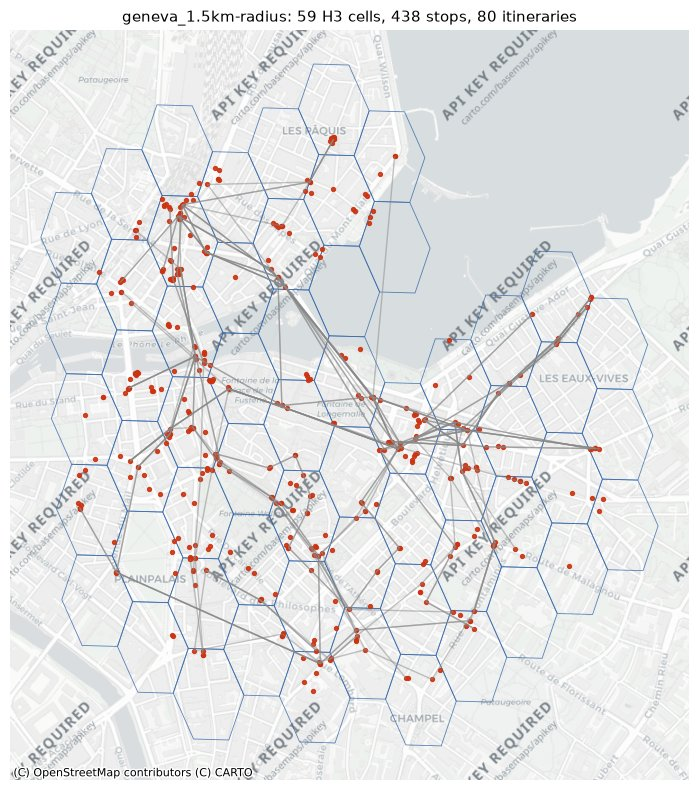

In [8]:
import contextily as cx

fig, ax = plt.subplots(figsize=(8, 8))
grid.to_crs(3857).plot(ax=ax, facecolor="none", edgecolor="#3366aa", linewidth=0.6, alpha=0.8)
itineraries.to_crs(3857).plot(ax=ax, color="#888888", linewidth=1.0, alpha=0.5)
stops.to_crs(3857).plot(ax=ax, color="#cc3311", markersize=8, alpha=0.9)
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron, alpha=0.9)
ax.set_title(f"{h3_version}: {len(grid)} H3 cells, {len(stops)} stops, "
             f"{len(itineraries)} itineraries", fontsize=11)
ax.set_axis_off()
fig.tight_layout()
show_map(fig)

## Step 2 — Pre-process: origin-destination demand

`od.csv` is the one input the data package does not ship. It is derived from the observed bike
trips: each trip's start and end point is assigned to the zone whose hexagon **contains** it, and
trips are then counted per (origin, destination) pair. Trips that start and end in the same zone,
or that fall outside the grid, are dropped.

The assignment is done by point-in-polygon rather than by recomputing H3 cell ids, which keeps it
independent of the id convention used on either side.

[`demo/od_builder.py`](demo/od_builder.py) lives outside the frozen package, so it can also be run
on its own: `pipenv run python demo/od_builder.py`. It rewrites `od.csv` in place, and is
deterministic — running it again on the same trips gives a byte-identical file.

In [9]:
import pandas as pd
from sum_network_design_bss.od_builder import build_od_from_trips

build_od_from_trips(GEOJSON_DIR)

od = pd.read_csv(GEOJSON_DIR / "od.csv")
print(f"\n{int(od['flow'].sum())} inter-zone trips over {len(od)} OD pairs "
      f"(from {len(bike_trips)} observed trips)")
print(f"origin zones: {od['origin_cell'].nunique()} | "
      f"destination zones: {od['dest_cell'].nunique()}")
od.sort_values("flow", ascending=False).head()

✅ Saved: /network-design-bss/src/data/geojson/geneva_1.5km-radius/od.csv
   1658 trips read, 9 with an endpoint outside the grid, 1453 counted over 703 OD pairs

1453 inter-zone trips over 703 OD pairs (from 1658 observed trips)
origin zones: 54 | destination zones: 49


,origin_cell,dest_cell,flow
0,897a8dcac53ffff,897a8dc120fffff,24
1,897a8dcac5bffff,897a8dc120bffff,22
2,897a8dc120bffff,897a8dcac5bffff,21
3,897a8dcaccfffff,897a8dc127bffff,19
4,897a8dca1b3ffff,897a8dc1223ffff,18


## Step 3 — Build the instance

`generate_h3_instances()` assembles the scenario the model will solve: it loads the grid, the public
transport lines and stops, derives the candidate stations, reads the OD table and splits it into
time periods. The result is serialised to `h3_instances_json/` so it can be reloaded or compared
across runs.

The scenario is defined inline in
[`instance_builder.py`](../network-design-bss/src/instance_builder.py) — a total budget of 80 000 with
2.5 % of it operational, and demand split across 3 periods. The split is stochastic (a multinomial
draw over the period weights) but seeded, so the instance is reproducible.

In [10]:
from instance_builder import generate_h3_instances

instance = generate_h3_instances()

print("\nconfig name       :", instance.config_name)
print("grid zones        :", len(instance.grid_generator.grid_centers))
print("public transport  :", len(instance.public_transport.routes), "routes")
print("candidate stations:", len(instance.all_stations))
print("demand entries    :", len(instance.od_demand),
      "| total flow:", sum(instance.od_demand.values()))

[dedupe] route PT_2 duplicates PT_19, skipped.
[dedupe] route PT_G+ duplicates PT_E+, skipped.
[dedupe] route PT_G duplicates PT_E, skipped.
✅ Saved: h3_instances_json/Geneva_H3True_SEED20_DISmultinomial_P0.40-0.18-0.42_BUD80000_OP0.0250_SCALE1.00.txt

config name       : Geneva_H3True_SEED20_DISmultinomial_P0.40-0.18-0.42_BUD80000_OP0.0250_SCALE1.00
grid zones        : 56
public transport  : 26 routes
candidate stations: 100
demand entries    : 971 | total flow: 1453


## Step 4 — Build the multimodal network and enumerate shortest paths

Two things happen here.

`get_instance_attribute()` reloads the serialised instance and draws the grid, the candidate
stations and the stop map into `plot/`.

`get_shortest_path_solver()` then builds the multimodal graph — walk, bike and public transport arcs
over the OSM street network — and enumerates the `NUM_SHORTEST_PATHS` best paths for every OD pair
**twice**: once on a network without bike sharing, which is the baseline every time saving is
measured against, and once with all candidate stations available.

> **This is the slow step.** Cold, it takes about 50 minutes: roughly 50 s per origin zone, twice.
> The street graphs are cached in `osm_cache/` and the path sets in
> `data/shortest_paths_result/`, keyed by instance size and `k`, so a second run of the same
> instance reuses both and finishes in seconds.

In [11]:
import time
from input_handler.instance_attribute_extracter import get_instance_attribute
from main import get_shortest_path_solver

started = time.time()

config_name, demand_generator, grid_generator, public_transport, station_layout = \
    get_instance_attribute(instance)

network_with_bss, shortest_path_solver = get_shortest_path_solver(
    grid_generator, public_transport, station_layout)

print(f"\nbuilt in {time.time() - started:.0f} s")
print("network nodes:", network_with_bss.graph.number_of_nodes())
print("network arcs :", network_with_bss.graph.number_of_edges())

The total demand is 1453.
Period 0: total demand = 585, active OD pairs = 392, demand per OD = 1.49
Period 1: total demand = 245, active OD pairs = 192, demand per OD = 1.28
Period 2: total demand = 623, active OD pairs = 387, demand per OD = 1.61


/env/lib/python3.13/site-packages/contextily/tile.py:298: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tile_urls = [provider.build_url(x=tile.x, y=tile.y, z=tile.z) for tile in tiles]


[plot] Figure saved to: /network-design-bss/src/plot/H3_Grid_with_Candidate_Stations.png


/env/lib/python3.13/site-packages/contextily/tile.py:298: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tile_urls = [provider.build_url(x=tile.x, y=tile.y, z=tile.z) for tile in tiles]


[plot] PT stops figure saved to: /network-design-bss/src/plot/H3_Grid_with_PT_Stops.png
[SP cache] No cache found, start fresh
Grid center walks to userOD processed: 1540 arcs added.

Grid center walks to publicTransportStop processed: 4592 arcs added.

Node: 
  - userOD: 56
  - publicTransportStop: 82

 Arc:
  - Walk: 18906
  - PT: 186
[SP cache] Saved 9453 entries


Processing user OD nodes: 100%|██████████| 56/56 [00:55<00:00,  1.02it/s]


Quantity of multi-modal trips:
  - {'PT_A6', 'Walk'}: 60
  - {'Walk', 'PT_92'}: 102
  - {'Walk', 'PT_92', 'PT_33'}: 12
  - {'Walk', 'PT_20'}: 174
  - {'Walk'}: 581
  - {'PT_E+', 'Walk', 'PT_92'}: 30
  - {'PT_2', 'Walk', 'PT_92'}: 18
  - {'Walk', 'PT_92', 'PT_7'}: 9
  - {'Walk', 'PT_92', 'PT_10'}: 13
  - {'PT_E+', 'Walk', 'PT_92', 'PT_1'}: 1
  - {'PT_3', 'Walk', 'PT_91'}: 2
  - {'Walk', 'PT_92', 'PT_E'}: 4
  - {'PT_3', 'Walk'}: 12
  - {'PT_92', 'Walk', 'PT_20'}: 25
  - {'Walk', 'PT_33', 'PT_12'}: 30
  - {'Walk', 'PT_12'}: 210
  - {'Walk', 'PT_20', 'PT_12'}: 48
  - {'PT_2', 'Walk', 'PT_12'}: 44
  - {'Walk', 'PT_7', 'PT_12'}: 96
  - {'PT_6', 'Walk', 'PT_12'}: 23
  - {'PT_A6', 'Walk', 'PT_20'}: 2
  - {'Walk', 'PT_92', 'PT_12'}: 34
  - {'Walk', 'PT_20', 'PT_1', 'PT_12'}: 4
  - {'Walk', 'PT_25', 'PT_12'}: 47
  - {'Walk', 'PT_E', 'PT_12'}: 20
  - {'PT_8', 'Walk', 'PT_12'}: 11
  - {'Walk', 'PT_91'}: 34
  - {'Walk', 'PT_20', 'PT_1'}: 12
  - {'PT_12', 'Walk', 'PT_33'}: 30
  - {'PT_12', 'PT_10', 

Processing user OD nodes: 100%|██████████| 56/56 [29:43<00:00, 31.85s/it]

Quantity of multi-modal trips:
  - {'Bike', 'PT_A6', 'Walk'}: 73
  - {'Bike', 'Walk'}: 2583
  - {'Bike', 'Walk', 'PT_92'}: 568
  - {'Bike', 'Walk', 'PT_33'}: 157
  - {'Bike', 'Walk', 'PT_E'}: 130
  - {'Bike', 'Walk', 'PT_20'}: 176
  - {'Bike', 'Walk', 'PT_10'}: 294
  - {'Bike', 'Walk', 'PT_25', 'PT_10'}: 2
  - {'Bike', 'Walk', 'PT_12'}: 822
  - {'PT_G', 'Bike', 'Walk'}: 16
  - {'Bike', 'Walk', 'PT_6'}: 111
  - {'Bike', 'Walk', 'PT_7'}: 189
  - {'Bike', 'Walk', 'PT_18'}: 53
  - {'Bike', 'PT_2', 'Walk', 'PT_33'}: 10
  - {'Bike', 'Walk', 'PT_25'}: 245
  - {'Bike', 'PT_2', 'Walk'}: 307
  - {'Bike', 'PT_9', 'Walk'}: 204
  - {'Bike', 'PT_9', 'Walk', 'PT_33'}: 53
  - {'Bike', 'Walk', 'PT_1'}: 22
  - {'PT_8', 'Bike', 'Walk'}: 64
  - {'Bike', 'Walk', 'PT_5'}: 8
  - {'Bike', 'Walk', 'PT_91'}: 12
  - {'Bike', 'Walk', 'PT_92', 'PT_E'}: 23
  - {'Bike', 'Walk', 'PT_92', 'PT_33'}: 27
  - {'Walk', 'Bike', 'PT_25', 'PT_92', 'PT_12'}: 1
  - {'Bike', 'PT_E+', 'Walk'}: 32
  - {'Bike', 'PT_3', 'Walk'}: 8
 

### Sanity check on the arcs

Worth doing once on any new area, because it is where a wrong coordinate system shows up first.
Arcs are stored as `Arc` objects on the edge data (`network_constructor.py:155`), carrying a
distance in km and a travel time in minutes. Walk and bike arcs name their mode; a public transport
arc names the route it belongs to, so the routes are pooled below the way the frozen code pools
them for its own count (`network_constructor.py:135`).

Over a 1.5 km-radius area the numbers should be small and modal:

- **Walk** — a few hundred metres, at exactly `WALK_SPEED` (4 km/h), capped by the 0.3 km walking
  catchment of a station.
- **Bike** — up to the 1 km ride catchment, at `RIDE_SPEED` (20 km/h) **plus** a flat
  `BIKE_ACCESS_EGRESS_TIME` of 1 minute for unlocking and parking, which is why the implied speed
  comes out well below 20.
- **PT** — one arc per pair of consecutive stops, carrying the *scheduled* time from the GTFS feed
  rather than a distance divided by a speed, so no speed is implied for it.

Distances in the thousands of kilometres would mean the graph was measured in degrees on projected
coordinates — the defect the second runtime patch guards against.

In [12]:
from collections import defaultdict
from statistics import median

per_mode = defaultdict(list)
for _, _, data in network_with_bss.graph.edges(data=True):
    arc = data.get("arc")
    if arc is not None:
        bucket = "PT" if arc.mode.startswith("PT") else arc.mode
        per_mode[bucket].append((arc.distance, arc.travel_time))

arcs = pd.DataFrame({
    bucket: {
        "arcs": len(values),
        "median km": round(median(d for d, _ in values), 3),
        "max km": round(max(d for d, _ in values), 3),
        "median min": round(median(t for _, t in values), 2),
        "max min": round(max(t for _, t in values), 2),
    }
    for bucket, values in per_mode.items()
}).T.loc[[m for m in ("Walk", "Bike", "PT") if m in per_mode]]
arcs["arcs"] = arcs["arcs"].astype(int)

# A rough cross-check, and only meaningful where the time was derived from a
# speed in the first place -- which is not the case for public transport.
arcs["implied km/h"] = [
    round(60 * row["median km"] / row["median min"], 1)
    if mode in ("Walk", "Bike") and row["median min"] else None
    for mode, row in arcs.iterrows()
]
arcs

,arcs,median km,max km,median min,max min,implied km/h
Walk,1574,0.239,0.779,3.59,11.68,4.0
Bike,4116,0.687,1.729,3.06,6.19,13.5
PT,186,0.315,1.130,2.00,12.00,NaN


## Step 5 — Solve

`solve_mode="integrated"` solves the whole mixed-integer program in one shot, giving the exact
optimum: which stations to build, how large each one is, and how many bikes it holds in each
period, all decided together.

The other modes are `"sequential"` (two-stage: fix the design first, then optimise operations on
it), `"benders"` and `"alns"`. **`"benders"` and `"alns"` cannot run in this repository** — the
modules they need were never committed. See the closing notes of
[`simulation_demo.ipynb`](simulation_demo.ipynb).

Solving also writes the results: a Gurobi log and a result JSON under `data/output/`, and the
selected stations as GeoJSON under `data/output/geojson/`. Step 8 reads that GeoJSON back.

In [13]:
from model.sequential_optimization import optimization_model_solver
from util.util import EPSILON
import time
started = time.time()

bike_sharing_model = optimization_model_solver(
    demand_generator,
    EPSILON,                 # penalty weight on dispatch cost
    network_with_bss,
    shortest_path_solver,
    solve_mode="integrated",
)

gurobi_model = bike_sharing_model.model
print(f"\nsolved in {time.time() - started:.0f} s")
print("status     :", gurobi_model.Status, "(2 = optimal)")
print("objective  :", gurobi_model.ObjVal)
print("variables  :", gurobi_model.NumVars)
print("constraints:", gurobi_model.NumConstrs)

Set parameter Username
Set parameter LicenseID to value 2861409
Academic license - for non-commercial use only - expires 2027-09-08
=== Sets Initialization Completed ===
Total OD pairs (K): 3067
Total Bike Stations (B): 100
=== Parameters Initialization Completed ===
Start setting variables
=== Variables Initialization Completed ===
=== Objectives Initialization Completed ===
=== Constraints Initialization Completed ===
Final total constraints count: 0
Set parameter TimeLimit to value 3600
Set parameter MIPGap to value 0
🔍 TimeLimit parameter: 3600.0
Set parameter Method to value 3
---------------------------
Statistics for model 'NetworkDesign':
  Problem type                : MIP
  Linear constraint matrix    : 36459 rows, 53520 columns, 145507 nonzeros
  Variable types              : 0 continuous, 53520 integer (1864 binary)
  Matrix range                : [1e+00, 1e+02]
  Objective range             : [7e-01, 3e+00]
  Bounds range                : [1e+00, 3e+01]
  RHS range        

## Step 6 — Post-process: reporting metrics

`ExperimentHandler` computes the reporting metrics and appends one row to `experiment_results.csv`:
how many stations were selected, their capacities and fill ratios, the share of OD demand covered,
the travel time saved against the no-bike-sharing baseline, and the rebalancing effort.

Constructing it is enough — `__init__` calls `record()` and `save()` itself
(`experiment.py:39`), so calling them again would append the same row twice. `last_row` holds the
metrics as a plain dict.

In [14]:
from output_handler.experiment import ExperimentHandler

experiment = ExperimentHandler(bike_sharing_model, network_with_bss, config_name)
summary = experiment.last_row

pd.Series({k: summary[k] for k in [
    "n_candidates", "n_selected_stations", "n_reg_station", "n_trans_station",
    "avg_capacity_reg", "avg_capacity_trans", "fill_ratio_reg", "fill_ratio_trans",
    "covered_od_ratio", "total_time_gain", "average_time_gain",
    "flow_bike_only", "flow_bike_pt", "dispatch_count", "obj_val",
] if k in summary}).to_frame("value")

,value
n_candidates,100.000000
n_selected_stations,81.000000
n_reg_station,52.000000
n_trans_station,29.000000
avg_capacity_reg,14.500000
avg_capacity_trans,11.896552
fill_ratio_reg,0.681829
fill_ratio_trans,0.605054
covered_od_ratio,0.932000
total_time_gain,7322.304722


Reading the row:

- **`n_selected_stations` against `n_candidates`** — how tight the investment budget is. Fewer
  selected than available means the budget binds.
- **`n_reg_station` / `n_trans_station`** — plain zone-centre stations against stations co-located
  with a public transport stop. The transfer stations are what make a trip multimodal.
- **`covered_od_ratio`** — the share of OD demand that ends up using a bike leg. `OD_COVERAGE_RATIO`
  in `util/util.py` sets the floor the model must respect.
- **`total_time_gain` / `average_time_gain`** — minutes saved against the baseline network from
  step 4, in total and per covered trip.
- **`flow_bike_only` / `flow_bike_pt`** — the covered trips split by whether they used public
  transport as well as a bike.

**The derived metrics move a little between runs.** The frozen model sets Gurobi's `Method` to `3`
(`model_template.py:81`), which is concurrent optimisation — documented as non-deterministic — and
no seed is fixed. This instance has alternative optima, so the objective and the station counts come
out identical every time while the flow split and coverage shift slightly. `simulation_demo.ipynb`
records the spread measured over eight runs.

## Step 7 — Post-process: the selected design

`get_design_solution()` returns the three design variables per candidate station: `y` (built or
not), `w` (capacity, in bikes) and `v1` (bikes stocked at the start of the first period).

In [15]:
design = bike_sharing_model.get_design_solution()

stations = pd.DataFrame([
    {
        "station": getattr(node, "node_id", str(node)),
        "type": getattr(node, "type", type(node).__name__),
        "lon": node.coordinate[0],
        "lat": node.coordinate[1],
        "capacity": round(design["w"][node], 1),
        "initial bikes": round(design["v1"][node], 1),
    }
    for node, built in design["y"].items() if built > 0.5
]).sort_values("capacity", ascending=False).reset_index(drop=True)

print(f"{len(stations)} of {len(design['y'])} candidate stations selected")
print(f"total capacity {stations['capacity'].sum():.0f} bikes, "
      f"stocked with {stations['initial bikes'].sum():.0f} at the start of period 1\n")
print(stations["type"].value_counts().to_string())
stations.head(15)

81 of 100 candidate stations selected
total capacity 1099 bikes, stocked with 832 at the start of period 1

type
BikeStation        52
TransferStation    29


,station,type,lon,lat,capacity,initial bikes
0,BS-897a8dcac53ffff,BikeStation,6.160517,46.203704,30.0,29.0
1,transfer_PT_12-5,TransferStation,6.152867,46.201719,30.0,30.0
2,transfer_PT_25-4,TransferStation,6.146992,46.207346,30.0,5.0
3,transfer_PT_25-3,TransferStation,6.151519,46.203398,30.0,30.0
4,transfer_PT_12-4,TransferStation,6.147405,46.203019,30.0,30.0
5,BS-897a8dc120bffff,BikeStation,6.142443,46.208527,30.0,30.0
6,BS-897a8dc1247ffff,BikeStation,6.144847,46.209971,30.0,30.0
7,BS-897a8dca1a3ffff,BikeStation,6.152308,46.211317,30.0,30.0
8,BS-897a8dc1277ffff,BikeStation,6.145346,46.203998,30.0,30.0
9,BS-897a8dcacd7ffff,BikeStation,6.153057,46.202358,30.0,28.0


## Step 8 — Visualise the design on a real map

The solve in step 5 already wrote the selected stations to
`data/output/geojson/selected_bike_stations.geojson_<timestamp>.geojson`.
`plot_bike_stations_with_pt()` picks up the most recent of those and draws two maps into
`data/output/geojson_map/`: the stations alone, and the stations over the public transport lines.
Marker size and colour both encode capacity.

Those files are written at 300 dpi and run to about 3 MB each, so what is embedded below is a
downscaled preview. The originals stay on disk.

🗂️ 使用最新站点: selected_bike_stations.geojson_2026-09-08_15-21-53.geojson


/env/lib/python3.13/site-packages/contextily/tile.py:298: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tile_urls = [provider.build_url(x=tile.x, y=tile.y, z=tile.z) for tile in tiles]


✅ Map saved -> /network-design-bss/src/data/output/geojson_map/geneva_bike_stations_2026-09-08_15-23-13.png


/env/lib/python3.13/site-packages/contextily/tile.py:298: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tile_urls = [provider.build_url(x=tile.x, y=tile.y, z=tile.z) for tile in tiles]


✅ Map saved -> /network-design-bss/src/data/output/geojson_map/geneva_bike_stations_with_lines_2026-09-08_15-23-13.png


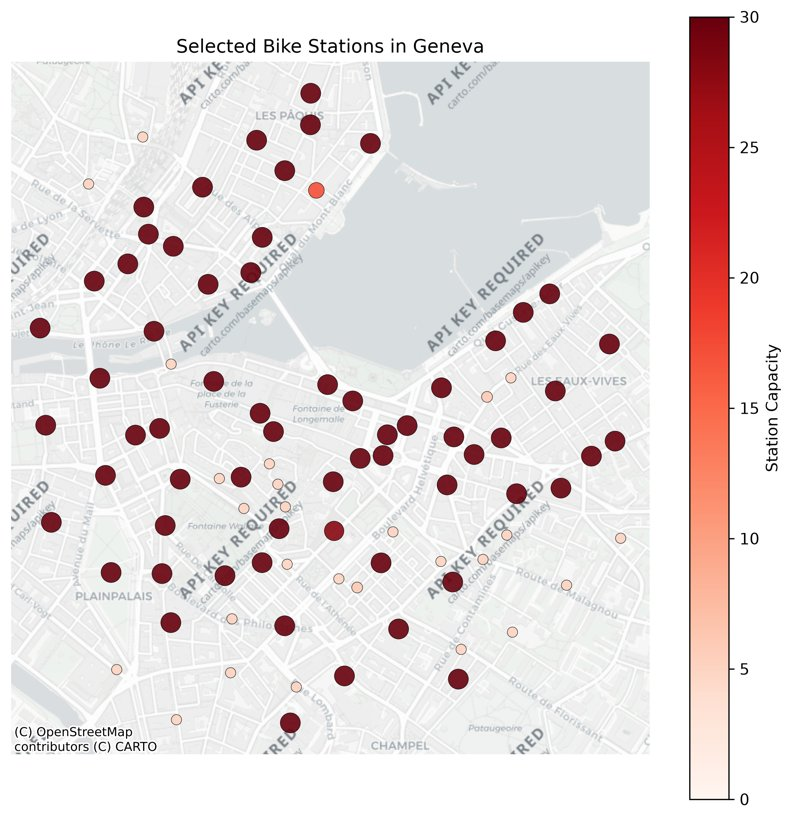

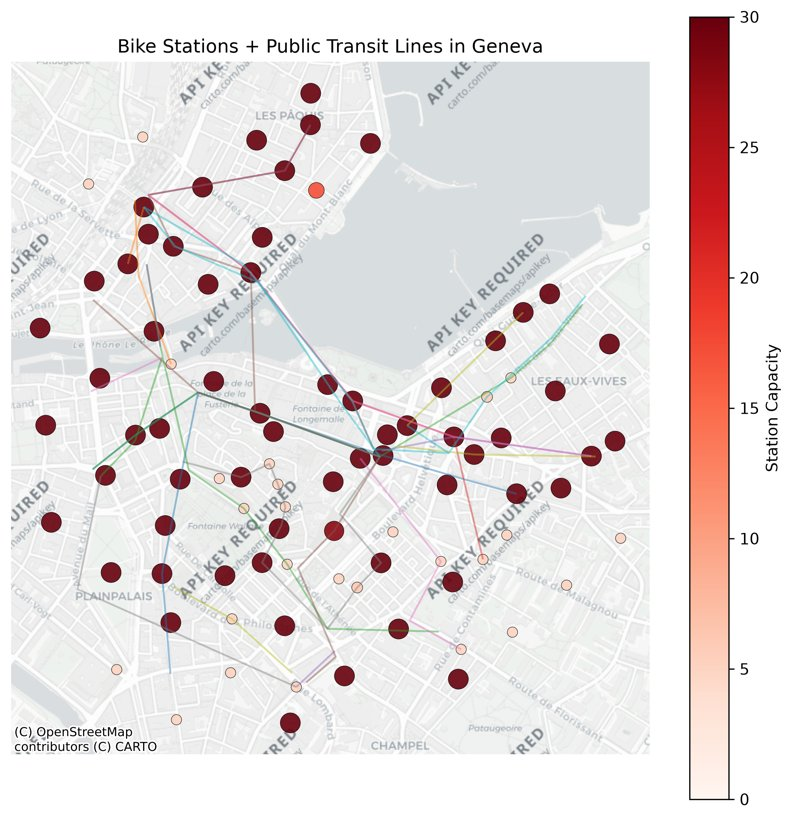

In [16]:
from result_visualization.realmap_station_viewer import plot_bike_stations_with_pt

stations_png, stations_with_lines_png = plot_bike_stations_with_pt(
    public_transport, grid_generator.grid_centers, demand_generator.demand_matrix)

for path in (stations_png, stations_with_lines_png):
    show_map(path)

## What the run left on disk

All paths are relative to `network-design-bss/src/`, because `bootstrap()` made it the working
directory. They are covered by `network-design-bss/src/.gitignore`, so a run does not dirty the frozen
package.

| Path | Contents |
|---|---|
| `h3_instances_json/` | the serialised instance from step 3 |
| `osm_cache/` | OSM street graphs, per travel mode |
| `data/shortest_paths_result/` | the enumerated path sets from step 4 |
| `plot/` | grid, candidate-station and stop maps drawn during step 4 |
| `data/output/` | Gurobi log and result JSON per solve |
| `data/output/geojson/` | selected stations, one timestamped GeoJSON per solve |
| `data/output/geojson_map/` | the two PNG maps from step 8 |
| `experiment_results.csv` | one row per solve, appended |

`data/output/geojson/` is also what feeds the
[dynamic demonstration map](https://inria.github.io/inocs-sum-bss-pt-network-design).

## Where to go next

- **Change the model's behaviour** — the parameters are module-level constants in
  [`util/util.py`](../network-design-bss/src/util/util.py), read at import time, so they have to be changed
  before the model modules are imported. `simulation_demo.ipynb` documents them.
- **Change the scenario** — budget and demand split are per-scenario instead, set through
  `ScenarioConfig` in [`scenario/scenario_config.py`](../network-design-bss/src/scenario/scenario_config.py)
  and assembled in `instance_builder.generate_h3_instances`.
- **Change the area** — regenerate the sample at a different radius or resolution with the companion
  package (step 1). `h3_version`, `H3_resolution`, `CENTER_LON/LAT` and `RADIUS` in `util/util.py`
  are frozen, so a new sample directory has to be named to match them, or those constants overridden
  before import.
- **Run it without a notebook** — `PYTHONPATH=network-design-bss/sdk-builder pipenv run python -c "from sum_network_design_bss.compat import bootstrap;
  bootstrap(); import main; main.main_run_single_instance(main.generate_h3_instances(),
  epsilon=0.04)"` does steps 3 to 8 in one call. It prints
  `[verify] Skipped due to error: No module named 'alns'` on the way past: that is the optional
  LP-oracle cross-check, which needs one of the modules that were never committed. The solve and
  every output are unaffected.
- **Known gaps in the frozen code** — listed at the end of
  [`simulation_demo.ipynb`](simulation_demo.ipynb).